[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jen1995/jen1995.github.io/blob/main/notebooks/reading_the_dft.ipynb)

This notebook accompanies the post [From the Fourier Series to the Spectrogram, Part 2: Reading the DFT](https://jen1995.github.io/posts/fourier-series-to-spectrogram-part-2/): every computation from the post, runnable — plus the corner cases the post glossed over. Pure numpy + matplotlib, runs anywhere in seconds.

# Reading the DFT — with code

The plan mirrors the post, then goes further:

1. a signal with known ingredients, and where they land in `np.fft.fft`;
2. bins → hertz, and the frequency resolution $\Delta f = f_s / N$ (the B3-vs-C4 experiment);
3. the mirror $X[N-k] = \overline{X[k]}$, verified numerically;
4. **amplitude bookkeeping**: recovering the honest amplitudes from a one-sided spectrum — the factor of 2, and the two bins it does *not* apply to;
5. **corner case:** the sine that vanishes at exactly the Nyquist frequency;
6. **corner case:** even vs odd $N$ — where the Nyquist bin lives, and where it doesn't;
7. `rfft`: the library that simply refuses to compute the mirror.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

BLUE, ORANGE, VIOLET, GREY = "#2a78d6", "#eb6834", "#4a3aa7", "#8a8983"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

## 1. A signal with known ingredients

Same signal as in the post: three sines with amplitudes 3, 1, 0.5 at 1, 5, 7 Hz,
sampled for one second at $f_s = 100$ Hz — so $N = 100$ samples, and every
component completes a whole number of turns per recording (no leakage to worry
about; that story belongs to Part 3).

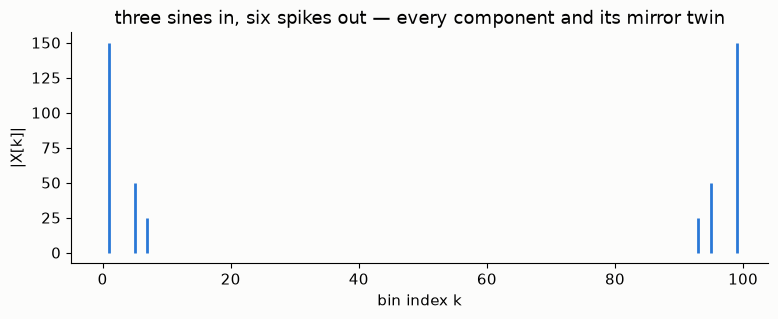

In [2]:
fs, N = 100, 100
n = np.arange(N)
t = n / fs

x = 3 * np.sin(2 * np.pi * 1 * t) + 1 * np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 7 * t)
X = np.fft.fft(x)

plt.figure(figsize=(9, 3))
plt.vlines(n, 0, np.abs(X), color=BLUE, lw=2)
plt.xlabel("bin index k"); plt.ylabel("|X[k]|")
plt.title("three sines in, six spikes out — every component and its mirror twin")
plt.show()

The components sit at $k = 1, 5, 7$ — and their twins at $N-k = 99, 95, 93$.
Each spike has height $N \cdot A / 2$: the amplitude of a real sine is split
evenly between the forward- and the backward-rotating exponential.

In [3]:
for k, A in [(1, 3.0), (5, 1.0), (7, 0.5)]:
    print(f"k = {k:2d}:  |X[k]| = {np.abs(X[k]):6.1f}   (N·A/2 = {N * A / 2:6.1f}),   "
          f"twin |X[N-k]| = {np.abs(X[N - k]):6.1f}")

k =  1:  |X[k]| =  150.0   (N·A/2 =  150.0),   twin |X[N-k]| =  150.0
k =  5:  |X[k]| =   50.0   (N·A/2 =   50.0),   twin |X[N-k]| =   50.0
k =  7:  |X[k]| =   25.0   (N·A/2 =   25.0),   twin |X[N-k]| =   25.0


## 2. Bins to hertz, and the price of resolution

The $k$-th bin is the physical frequency $f_k = k \, f_s / N$. numpy ships a
helper that does this arithmetic — and it labels the upper half of the bins
with **negative** frequencies, agreeing with the post: the mirror half *is*
the negative-frequency half, wrapped around by periodicity.

In [4]:
freqs = np.fft.fftfreq(N, d=1 / fs)
print("lower half:", freqs[:5], "...")
print("upper half: ...", freqs[-4:], "  <- negative frequencies")
assert np.allclose(freqs[N // 2 + 1:], np.arange(N // 2 + 1, N) * fs / N - fs)

lower half: [0. 1. 2. 3. 4.] ...
upper half: ... [-4. -3. -2. -1.]   <- negative frequencies


Now the B3-vs-C4 experiment from the post: two notes 15 Hz apart at
$f_s = 8000$ Hz. First the bookkeeping — which *cell* of the frequency grid
does each note fall into (i.e., which probe is nearest)?

In [5]:
fs2, B3, C4 = 8000, 247.0, 262.0
for N2 in [100, 530, 2120]:
    df = fs2 / N2
    kB, kC = round(B3 / df), round(C4 / df)
    verdict = "the same cell!" if kB == kC else "different cells"
    print(f"N = {N2:4d}: Δf = {df:5.2f} Hz — B3 -> k = {kB}, C4 -> k = {kC}:  {verdict}")

N =  100: Δf = 80.00 Hz — B3 -> k = 3, C4 -> k = 3:  the same cell!
N =  530: Δf = 15.09 Hz — B3 -> k = 16, C4 -> k = 17:  different cells
N = 2120: Δf =  3.77 Hz — B3 -> k = 65, C4 -> k = 69:  different cells


At $N = 530$ the two notes get separate cells, as the post promised. But
"separate cells" is the *threshold* of resolution, not comfort — look at the
actual spectra:

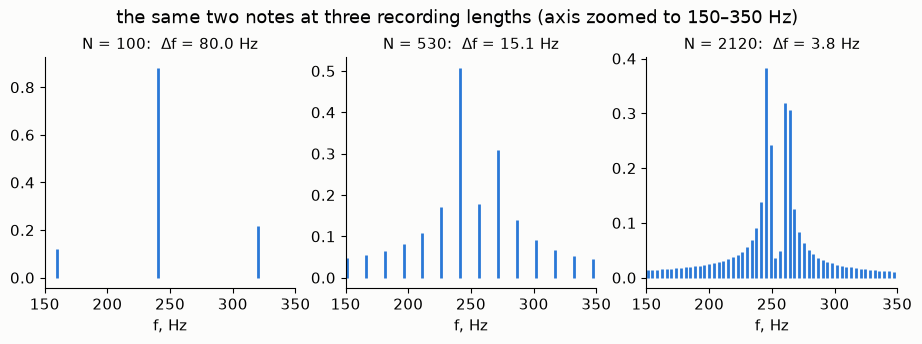

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, N2 in zip(axes, [100, 530, 2120]):
    t2 = np.arange(N2) / fs2
    two = np.sin(2 * np.pi * B3 * t2) + np.sin(2 * np.pi * C4 * t2)
    S = np.abs(np.fft.rfft(two)) / N2
    f2 = np.arange(len(S)) * fs2 / N2
    ax.vlines(f2, 0, S, color=BLUE, lw=2)
    ax.set_xlim(150, 350)
    ax.set_title(f"N = {N2}:  Δf = {fs2 / N2:.1f} Hz", fontsize=10.5)
    ax.set_xlabel("f, Hz")
fig.suptitle("the same two notes at three recording lengths (axis zoomed to 150–350 Hz)", y=1.04)
plt.show()

Three regimes, one lesson each:

* $N = 100$, $\Delta f = 80$ Hz $\gg$ gap: **one blob** — hopeless, as expected.
* $N = 530$, $\Delta f \approx$ gap: the notes hold separate cells on paper, but
  the peaks barely disentangle — and notice the *dip* between them: neither
  note sits exactly on a grid frequency, so each smears across neighboring
  bins, and the two smears interfere. (That smearing is **spectral leakage** —
  the "not in the vocabulary" effect from the post, and Part 3's main
  antagonist.)
* $N = 2120$ (a quarter second), $\Delta f \approx 3.8$ Hz $\ll$ gap: two
  unmistakable peaks.

So read $\Delta f$ as the threshold below which separation is *impossible*;
comfortable separation wants a margin on top.

## 3. The mirror, verified

The post proved $X[N-k] = \overline{X[k]}$ for every real signal in four
lines. A computer checks it in one — and note that the proof used the
*realness* of the samples, so complex input must break the symmetry:

In [7]:
rng = np.random.default_rng(0)

x_real = rng.standard_normal(256)
Xr = np.fft.fft(x_real)
print("real input, mirror holds:   ", np.allclose(Xr[1:][::-1], np.conj(Xr[1:])))

x_cplx = rng.standard_normal(256) + 1j * rng.standard_normal(256)
Xc = np.fft.fft(x_cplx)
print("complex input, mirror holds:", np.allclose(Xc[1:][::-1], np.conj(Xc[1:])))

real input, mirror holds:    True
complex input, mirror holds: False


## 4. Amplitude bookkeeping: the factor of 2 (and its two exceptions)

In practice you keep only the informative half of the spectrum — and if you
then want honest *amplitudes*, you must remember that every interior spike
holds only **half** of its sine's amplitude, the other half living in the
discarded twin. So the one-sided amplitude spectrum is

$$A_k = \frac{2\,|X[k]|}{N} \quad \text{— except at the two bins that have no twin:}$$

* $k = 0$ (DC): its mirror is $N - 0 = N \equiv 0$ — it *is* its own twin. No doubling: $A_0 = |X[0]| / N$.
* $k = N/2$ (Nyquist, even $N$ only): its mirror is $N - N/2 = N/2$ — again its own twin. No doubling: $A_{N/2} = |X[N/2]| / N$.

This is exactly the machinery scipy applies inside its one-sided spectra: the
[`scipy.signal.periodogram` docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html)
say *"if return_onesided is True, the values of the negative frequencies are
added to values of the corresponding positive ones"* — and DC and Nyquist have
no negative counterpart to collect.

A signal that exercises all three cases: a DC offset of 2, a 5 Hz sine of
amplitude 3, and a cosine of amplitude 0.8 at exactly $f_s/2$:

In [8]:
x4 = 2.0 + 3.0 * np.sin(2 * np.pi * 5 * t) + 0.8 * np.cos(2 * np.pi * (fs / 2) * t)
X4 = np.fft.rfft(x4)

A = 2 * np.abs(X4) / N     # the general rule...
A[0] /= 2                  # ...and its two exceptions
A[-1] /= 2                 # (the last rfft bin IS the Nyquist bin, since N is even)

print(f"recovered DC        : {A[0]:.3f}   (true: 2.0)")
print(f"recovered A at 5 Hz : {A[5]:.3f}   (true: 3.0)")
print(f"recovered A at fs/2 : {A[-1]:.3f}   (true: 0.8)")

recovered DC        : 2.000   (true: 2.0)
recovered A at 5 Hz : 3.000   (true: 3.0)
recovered A at fs/2 : 0.800   (true: 0.8)


Forget the exceptions and the DC comes out double and the Nyquist component
double — a classic off-by-factor-of-two that has haunted many a lab report.

## 5. Corner case: the sine that vanishes at Nyquist

Why did the last section put a *cosine* at $f_s/2$? Because a **sine** at the
Nyquist frequency dies at the sampling stage: its zero crossings land exactly
on the sampling grid,

$$\sin\!\big(2 \pi \tfrac{f_s}{2} \tfrac{n}{f_s}\big) = \sin(\pi n) = 0 \quad \text{for every integer } n.$$

largest sample of a Nyquist sine: 3.1365813593450365e-14


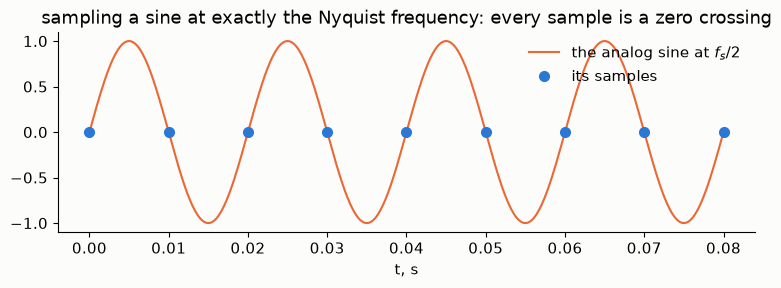

In [9]:
y = np.sin(2 * np.pi * (fs / 2) * t)
print("largest sample of a Nyquist sine:", np.abs(y).max())   # numerically zero

tt = np.linspace(0, 4 / (fs / 2), 500)
plt.figure(figsize=(9, 2.6))
plt.plot(tt, np.sin(2 * np.pi * (fs / 2) * tt), color=ORANGE, lw=1.5,
         label="the analog sine at $f_s/2$")
nn = np.arange(int(4 / (fs / 2) * fs) + 1)
plt.plot(nn / fs, np.sin(np.pi * nn), "o", color=BLUE, ms=7, label="its samples")
plt.legend(loc="upper right", frameon=False)
plt.title("sampling a sine at exactly the Nyquist frequency: every sample is a zero crossing")
plt.xlabel("t, s")
plt.show()

The grid catches the oscillation at every zero crossing and sees nothing at
all. A cosine at the same frequency — shifted by a quarter period — is caught
at its peaks instead, and survives with its amplitude intact. Anything in
between keeps only its cosine component: at exactly $f_s/2$, the *phase* of an
oscillation is unrecoverable (the Nyquist bin is purely real — no angle to
store it in). This is the fine print behind the sampling theorem's "no
frequencies higher than $f$": at *exactly* the boundary, sampling at $2f$ is
not enough. The theorem's own post will return to this.

## 6. Corner case: odd N has no Nyquist bin

The Nyquist *frequency* $f_s/2$ always exists — but the Nyquist *bin* requires
$k = N/2$ to be an integer. For odd $N$ the mirror axis falls **between** two
bins, and no probe sits on it:

In [10]:
for N6 in [8, 9]:
    f6 = np.fft.rfftfreq(N6, d=1 / fs)
    print(f"N = {N6}:  rfft returns {len(f6)} bins, highest at {f6[-1]:.2f} Hz "
          f"(Nyquist is {fs / 2:.1f} Hz){'  <- lands exactly on Nyquist' if np.isclose(f6[-1], fs / 2) else '  <- falls short: no Nyquist bin'}")

N = 8:  rfft returns 5 bins, highest at 50.00 Hz (Nyquist is 50.0 Hz)  <- lands exactly on Nyquist
N = 9:  rfft returns 5 bins, highest at 44.44 Hz (Nyquist is 50.0 Hz)  <- falls short: no Nyquist bin


The information bookkeeping adjusts itself accordingly (this is the post's
"do the books still balance?" inset, now for both parities):

| $N$ | real bins | complex pairs | real numbers total |
|---|---|---|---|
| even | $X[0]$, $X[N/2]$ | $N/2 - 1$ | $2 + 2(N/2 - 1) = N$ ✓ |
| odd  | $X[0]$ only      | $(N-1)/2$ | $1 + 2 \cdot \frac{N-1}{2} = N$ ✓ |

Verify the "purely real" claims directly:

In [11]:
for N6 in [8, 9]:
    z = rng.standard_normal(N6)
    Z = np.fft.fft(z)
    nyq_imag = np.imag(Z[N6 // 2]) if N6 % 2 == 0 else None
    print(f"N = {N6}:  Im X[0] = {np.imag(Z[0]):+.2e}", end="")
    if nyq_imag is not None:
        print(f",  Im X[N/2] = {nyq_imag:+.2e}   (both real, as promised)")
    else:
        print(f",  Im X[(N-1)/2] = {np.imag(Z[(N6 - 1) // 2]):+.2e}   (NOT real — it is a normal bin with a twin)")

N = 8:  Im X[0] = +0.00e+00,  Im X[N/2] = +0.00e+00   (both real, as promised)
N = 9:  Im X[0] = +0.00e+00,  Im X[(N-1)/2] = -4.46e+00   (NOT real — it is a normal bin with a twin)


## 7. rfft: the library refuses to compute the mirror

Since the upper half of a real signal's spectrum carries no information,
`np.fft.rfft` (and `scipy.fft.rfft`) simply does not compute it — the
[scipy docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fft.rfft.html)
spell out both facts we have just verified: *"If n is even, the length of the
transformed axis is (n/2)+1"* (odd: $(n+1)/2$), and for even $n$ the last
element *"contains the term representing both positive and negative Nyquist
frequency (+fs/2 and -fs/2), and must also be purely real"*.

In [12]:
assert np.allclose(np.fft.rfft(x), np.fft.fft(x)[: N // 2 + 1])
print("rfft(x) == fft(x)[:N//2+1]  — the mirror was never computed, nothing was lost")

rfft(x) == fft(x)[:N//2+1]  — the mirror was never computed, nothing was lost


---

**What we now know how to do:** place any physical frequency into its bin,
budget $\Delta f$ by the recording length, trust exactly half of the DFT's
output (plus the two self-twinned bins), and recover honest amplitudes with
the factor-of-2 rule. In Part 3 the DFT starts sliding along the signal — and
the resolution bill from section 2 becomes the central design decision of the
spectrogram.